## Previsione con Regressione Lineare Semplice - Principiante/Intermedio

Introduzione alla modellazione predittiva.
- Obiettivo: Prevedere un valore numerico (variabile target) basandosi su una o più variabili predittive (features) usando la Regressione Lineare. Un buon dataset è quello sui prezzi delle case (es. Boston Housing o un set più moderno).
- Competenze Python Richieste:
  - Scikit-learn (sklearn): Importazione e addestramento del modello LinearRegression.
  - Suddivisione dei dati: train_test_split per separare i dati di addestramento e di test.
  - Metriche di Valutazione: Calcolo di $R^2$, Errore Quadratico Medio (MSE) e Errore Assoluto Medio (MAE) per valutare le performance del modello.
- Risultato Atteso: Un modello in grado di fare previsioni e una sezione di valutazione che spiega quanto sia "buono" il modello in base alle metriche scelte.

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [3]:
df = pd.read_csv('prezzidellecase.csv')
df

,Superficie_mq,Camere,Bagni,Distanza_centro_km,Anno_costruzione,Piano,Prezzo_euro
0,45,2,1,8.5,1995,1,145000
1,78,3,2,4.2,2008,3,280000
2,120,4,2,2.1,2015,2,460000
3,95,3,2,3.5,2010,4,350000
4,60,2,1,6.8,2001,2,190000
5,110,4,2,1.8,2018,5,510000
6,75,3,1,5.2,2005,1,260000
7,52,2,1,7.3,1998,0,160000
8,89,3,2,3.0,2012,2,330000
9,130,5,3,1.5,2020,6,620000


In [4]:
df.describe()

,Superficie_mq,Camere,Bagni,Distanza_centro_km,Anno_costruzione,Piano,Prezzo_euro
count,51.000000,51.000000,51.000000,51.000000,51.000000,51.000000,51.000000
mean,91.823529,3.156863,1.843137,3.872549,2009.588235,2.823529,367058.823529
std,28.833804,1.065318,0.731370,2.435658,8.075089,2.224463,182784.508289
min,45.000000,1.000000,1.000000,0.400000,1995.000000,0.000000,140000.000000
25%,69.500000,2.000000,1.000000,1.850000,2003.000000,1.000000,217500.000000
50%,89.000000,3.000000,2.000000,3.400000,2010.000000,2.000000,330000.000000
75%,116.500000,4.000000,2.000000,5.850000,2016.500000,4.000000,475000.000000
max,150.000000,5.000000,3.000000,8.800000,2023.000000,8.000000,770000.000000


In [5]:
df.head()

,Superficie_mq,Camere,Bagni,Distanza_centro_km,Anno_costruzione,Piano,Prezzo_euro
0,45,2,1,8.5,1995,1,145000
1,78,3,2,4.2,2008,3,280000
2,120,4,2,2.1,2015,2,460000
3,95,3,2,3.5,2010,4,350000
4,60,2,1,6.8,2001,2,190000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51 entries, 0 to 50
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Superficie_mq       51 non-null     int64  
 1   Camere              51 non-null     int64  
 2   Bagni               51 non-null     int64  
 3   Distanza_centro_km  51 non-null     float64
 4   Anno_costruzione    51 non-null     int64  
 5   Piano               51 non-null     int64  
 6   Prezzo_euro         51 non-null     int64  
dtypes: float64(1), int64(6)
memory usage: 2.9 KB


In [7]:
from sklearn.linear_model import LinearRegression

In [8]:
X = df[['Distanza_centro_km']]
y = df['Prezzo_euro']

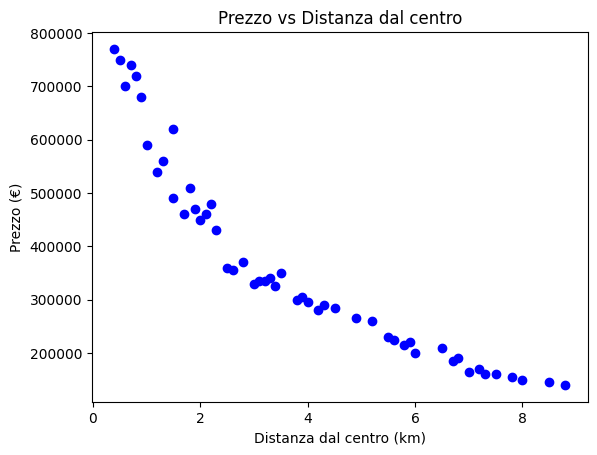

In [9]:
# Visualizziamo i dati
plt.scatter(X, y, color='blue')
plt.xlabel('Distanza dal centro (km)')
plt.ylabel('Prezzo (€)')
plt.title('Prezzo vs Distanza dal centro')
plt.show()

In [10]:
# Inizializziamo il modello di regressione lineare
model = LinearRegression()

# Addestriamo il modello sui dati
model.fit(X, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [11]:
# Otteniamo l'intercetta e il coefficiente angolare
intercept = model.intercept_
coefficient = model.coef_[0]

print(f'Intercetta (β₀): {intercept}')
print(f'Coefficiente Angolare (β₁): {coefficient}')

Intercetta (β₀): 634515.7558650688
Coefficiente Angolare (β₁): -69064.82809680256


In [12]:
# Facciamo previsioni sui dati di input
y_pred = model.predict(X)
y_pred

array([ 47464.71704225, 344443.4778585 , 489479.61686178, 392788.85752626,
       164874.92480681, 510199.06529082, 275378.6497617 , 130342.51075841,
       427321.27157466, 530918.51371986, 441134.23719402, 185594.37323585,
       579263.89338763, 358256.44347786,  95810.09671001, 482573.1340521 ,
       406601.82314562, 227033.27009393, 565450.92776827, 599983.34181667,
       323724.02942946, 151061.95918745, 461853.68562306, 503292.58248114,
       247752.71852297, 572357.41057795, 372069.40909722,  81997.13109065,
       413508.3059553 , 586170.37619731, 296098.09819074, 171781.40761649,
       544731.47933923, 399695.34033594, 116529.54513905, 593076.85900699,
       337536.99504882, 220126.78728425, 496386.09967146, 420414.78876498,
       254659.20133265, 551637.96214891, 137248.99356809, 454947.20281338,
       517105.5481005 , 233939.75290361, 606889.82462635, 365162.92628754,
        26745.26861321, 530918.51371986, 475666.65124242])

In [13]:
from sklearn.metrics import mean_squared_error, r2_score

# Calcoliamo l'errore quadratico medio e 
# il coefficiente di determinazione
mse = mean_squared_error(y, y_pred)
r2 = r2_score(y, y_pred)

print(f'Errore Quadratico Medio (MSE): {mse}')
print(f'Coefficiente di Determinazione (R²): {r2}')

Errore Quadratico Medio (MSE): 5012522154.204332
Coefficiente di Determinazione (R²): 0.8469696021573154


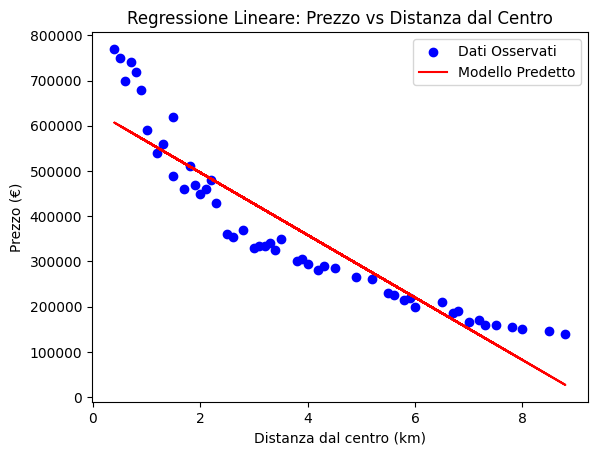

In [14]:
# Visualizziamo i risultati
plt.scatter(X, y, color='blue', label='Dati Osservati')
plt.plot(X, y_pred, color='red', label='Modello Predetto')
plt.xlabel('Distanza dal centro (km)')
plt.ylabel('Prezzo (€)')
plt.title('Regressione Lineare: Prezzo vs Distanza dal Centro')
plt.legend()
plt.show()

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'MSE test: {mse:.2f}')
print(f'R² test: {r2:.3f}')


MSE test: 6693336666.63
R² test: 0.830
